Maria Navarro  
February 27, 2024  
Healthcare Data & Analytics Case Study: Insurance Claims Data & Analytics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Read text files
raw_inp = pd.read_csv('VTINP16_upd/VTINP16_upd.txt', delimiter=',')  # Assuming comma-separated values
#ed = pd.read_csv('VTED16/vted16.txt', delimiter=',')
#outp = pd.read_csv('VTOUTP16/VTOUTP16.txt', delimiter=',')
#rev = pd.read_csv('VTREVCODE16/VTREVCODE16.txt', delimiter=',')


C:\Users\mfncn\AppData\Local\Temp\ipykernel_16392\1242287771.py:2: DtypeWarning: Columns (2,5,8,54,55,73,74,75,76,78) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_inp = pd.read_csv('VTINP16_upd/VTINP16_upd.txt', delimiter=',')  # Assuming comma-separated values


In [3]:
hsa_patient_orig = pd.read_excel('codes.xlsx', sheet_name='HSA_Patient_Origin')
hospital_region_dest = pd.read_excel('codes.xlsx', sheet_name='HospitalRegion_Destination')

In [4]:
raw_inp

,hnum2,ATYPE,asour,intage,TXTZIP,sex,dstat,PPAY,CHRGS,DX1,...,AFLAG,UNIQ,ADMID_QTR,DISCD_QTR,CHRGS_HCIA,SCUD,DRG,MDC,sdf,GROUPER
0,11,3,1,14,050,2,6,1,67375.25,Z5189,...,1,254,4,1,67375.25,,949,23,0,33
1,11,3,3,14,050,1,2,1,22886,Z5189,...,0,265,4,1,22886,,949,23,0,33
2,11,3,1,14,057,2,2,1,120544.05,Z4789,...,0,271,4,1,120544.05,,560,8,0,33
3,11,3,1,14,051,2,6,1,32325.8,S72001D,...,0,285,4,1,32325.8,,561,8,0,33
4,11,3,1,12,050,2,6,7,29244.1,C3490,...,0,305,4,1,29244.1,,181,4,0,33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53662,5,1,3,12,05452,1,7,1,10714.04,I5023,...,0,1984299,4,4,10714.04,0,291,5,0,34
53663,5,1,3,3,054,2,5,6,3529.4,O2342,...,0,1984384,4,4,3529.4,0,781,14,0,34
53664,5,1,3,2,05446,2,5,8,7112.75,D693,...,0,1984386,4,4,7112.75,0,813,16,0,34
53665,5,1,2,14,054,1,8,1,13312.85,J9601,...,0,1984415,4,4,13312.85,0,189,4,0,34


In [5]:
raw_inp.columns
#hospital_region_dest.columns

Index(['hnum2', 'ATYPE', 'asour', 'intage', 'TXTZIP', 'sex', 'dstat', 'PPAY',
       'CHRGS', 'DX1', 'DX2', 'DX3', 'DX4', 'DX5', 'DX6', 'DX7', 'DX8', 'DX9',
       'DX10', 'DX11', 'DX12', 'DX13', 'DX14', 'DX15', 'DX16', 'DX17', 'DX18',
       'DX19', 'DX20', 'PX1', 'PX2', 'PX3', 'PX4', 'PX5', 'PX6', 'PX7', 'PX8',
       'PX9', 'PX10', 'PX11', 'PX12', 'PX13', 'PX14', 'PX15', 'PX16', 'PX17',
       'PX18', 'PX19', 'PX20', 'ECODE1', 'ECODE2', 'ECODE3', 'hsa', 'pdays',
       'ccsdx', 'ccsdxgrp', 'CCSPX', 'CCSPXGRP', 'ccsppx', 'ccsppxgrp',
       'ccsproc', 'ccsprocgrp', 'DY', 'RECNO', 'BTYPE', 'ERFLAG', 'cah',
       'vtres', 'OBSFLAG', 'AFLAG', 'UNIQ', 'ADMID_QTR', 'DISCD_QTR',
       'CHRGS_HCIA', 'SCUD', 'DRG', 'MDC', 'sdf', 'GROUPER'],
      dtype='object')

In [6]:
hsa_patient_orig['hsa'].value_counts()
#hospital_region_dest['hnum2'].value_counts()
#raw_inp['hsa'].value_counts()

hsa
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
13    1
98    1
99    1
Name: count, dtype: int64

In [20]:
inp = raw_inp.copy()

# Replace empty strings with NaN in the specified column
inp['MDC'] = raw_inp['MDC'].replace(' ', np.nan)

# Drop rows with null values in the 'MDC' column
inp = inp.dropna(subset=['MDC'])

# Convert 'CHRGS' column to numeric
#inp['CHRGS'] = pd.to_numeric(inp['CHRGS'], errors='coerce')

# Convert 'MDC' column to numeric
inp['MDC'] = inp['MDC'].astype(int)

major_payers = [1, 6, 7]

# Define condition
condition = inp['PPAY'].isin(major_payers)

inp = inp[condition]

# Creating new payer column
condition_medicare = inp['PPAY'] == 1
condition_commercial = (inp['PPAY'] == 6) | (inp['PPAY'] == 7)

inp.loc[condition_medicare, 'payer'] = 'medicare'
inp.loc[condition_commercial, 'payer'] = 'commercial'

# Merge inp with hsa_patient_orig based on hsa column
inp = pd.merge(inp, hsa_patient_orig, on='hsa', how='left')

# Merge inp with hospital_region_dest based on hsa column
inp = pd.merge(inp, hospital_region_dest, on='hnum2', how='left')

# Drop rows where HSA = 99  (Missing)
drop_missing_hsa = ((inp['hsa'] == 99) | (inp['hsa'] == 98)) #TEST MARIA
#drop_missing_hsa = ((inp['hsa'] == 99))
inp = inp[~drop_missing_hsa]

In [21]:
inp['MDC'].value_counts()

MDC
8     4877
5     4848
4     3987
6     3263
14    2587
15    2472
18    2191
1     2103
11    1566
7      990
19     945
10     939
9      745
23     627
21     406
16     402
20     258
17     239
3      225
13     172
12     168
24      82
2       25
22      17
25      11
Name: count, dtype: int64

In [22]:
inp['payer'].value_counts()

payer
medicare      21441
commercial    12704
Name: count, dtype: int64

In [65]:
# Filter by MDC
mdc =  5 # Define MDC
inp_2 = inp[inp['MDC']==mdc]


In [66]:
inp_2['payer'].value_counts()

payer
medicare      3831
commercial    1017
Name: count, dtype: int64

In [67]:
# For specified MDC, count number of customers for each RR

# Group by RR patient and RR hospital and get count of patients in each group
count = inp_2.groupby(['RR_patient', 'RR_hosp'])['payer'].value_counts().fillna(0).astype(int)
count_df = count.unstack(fill_value=0).reset_index()

# Total patients per patient region
# Calculate total commercial patients per patient region
count_df['total_commercial'] = count_df.groupby('RR_patient')['commercial'].transform('sum')
# Calculate total medicare patients per patient region
count_df['total_medicare'] = count_df.groupby('RR_patient')['medicare'].transform('sum')

# % of patients for each hospital region within each patient region
# Calculate percentage of commercial patients for each hospital region within each patient region
count_df['commercial_%'] = (count_df['commercial'] / count_df['total_commercial']) * 100
# Calculate percentage of medicare patients for each hospital region within each patient region
count_df['medicare_%'] = (count_df['medicare'] / count_df['total_medicare']) * 100

# Total patients per hospital region
# Calculate total commercial patients per hospital region
count_df['total_hospital_commercial'] = count_df.groupby('RR_hosp')['commercial'].transform('sum')
# Calculate total medicare patients per hospital region
count_df['total_hospital_medicare'] = count_df.groupby('RR_hosp')['medicare'].transform('sum')

# Total patients across all regions
# Calculate total commercial patients across all regions
total_commercial_patients = count_df['commercial'].sum()
# Calculate total medicare patients across all regions
total_medicare_patients = count_df['medicare'].sum()

# Market share for each hospital region
# Calculate commercial market share for each hospital region
count_df['Comm MarketShare'] = (count_df['total_hospital_commercial'] / total_commercial_patients) * 100
# Calculate medicare market share for each hospital region
count_df['Medi MarketShare'] = (count_df['total_hospital_medicare'] / total_medicare_patients) * 100

count_df

payer,RR_patient,RR_hosp,commercial,medicare,total_commercial,total_medicare,commercial_%,medicare_%,total_hospital_commercial,total_hospital_medicare,Comm MarketShare,Medi MarketShare
0,RR1,RR1,518,1417,522,1428,99.233716,99.229692,727,1862,71.484759,48.603498
1,RR1,RR2,3,5,522,1428,0.574713,0.350140,96,580,9.439528,15.139650
2,RR1,RR4,0,1,522,1428,0.000000,0.070028,53,414,5.211406,10.806578
3,RR1,RR5,1,5,522,1428,0.191571,0.350140,100,666,9.832842,17.384495
4,RR2,RR1,130,287,219,870,59.360731,32.988506,727,1862,71.484759,48.603498
5,RR2,RR2,88,557,219,870,40.182648,64.022989,96,580,9.439528,15.139650
6,RR2,RR3,0,6,219,870,0.000000,0.689655,41,309,4.031465,8.065779
7,RR2,RR4,1,20,219,870,0.456621,2.298851,53,414,5.211406,10.806578
8,RR3,RR1,8,34,51,347,15.686275,9.798271,727,1862,71.484759,48.603498
9,RR3,RR2,2,10,51,347,3.921569,2.881844,96,580,9.439528,15.139650


In [68]:
# Pivot Table with Counts
# Pivot table for commercial patients
commercial_pivot = count_df.pivot_table(index='RR_patient', columns='RR_hosp', values='commercial', fill_value=0, margins=True, aggfunc='sum').astype(int)

# Pivot table for medicare patients
medicare_pivot = count_df.pivot_table(index='RR_patient', columns='RR_hosp', values='medicare', fill_value=0, margins=True, aggfunc='sum').astype(int)

# Print the pivot tables
print("O-D matrix with counts for Commercial patients:")
print(commercial_pivot)

print("\nO-D matrix with counts for Medicare patients:")
print(medicare_pivot)

O-D matrix with counts for Commercial patients:
RR_hosp     RR1  RR2  RR3  RR4  RR5   All
RR_patient                               
RR1         518    3    0    0    1   522
RR2         130   88    0    1    0   219
RR3           8    2   41    0    0    51
RR4          10    3    0   48    3    64
RR5          61    0    0    4   96   161
All         727   96   41   53  100  1017

O-D matrix with counts for Medicare patients:
RR_hosp      RR1  RR2  RR3  RR4  RR5   All
RR_patient                                
RR1         1417    5    0    1    5  1428
RR2          287  557    6   20    0   870
RR3           34   10  301    1    1   347
RR4           26    8    1  387   13   435
RR5           98    0    1    5  647   751
All         1862  580  309  414  666  3831


In [69]:
# Pivot Table with Percentages
# Pivot table for commercial patients
commercial_pivot_perc = count_df.pivot_table(index='RR_patient', columns='RR_hosp', values='commercial_%', fill_value=0)
# Add a row for the total for each patient region
#commercial_pivot_perc['Total'] = commercial_pivot_perc.sum(axis=1)
# Add a row for the market share of each hospital region
commercial_market_share_row = count_df.pivot_table(index=None, columns='RR_hosp', values='Comm MarketShare', aggfunc='first')
#commercial_market_share_row.loc['Market Share'] = commercial_market_share_row.sum()
# Concatenate the market share row to the pivot table
commercial_pivot_final = pd.concat([commercial_pivot_perc, commercial_market_share_row]).round(2)

# Pivot table for medicare patients
medicare_pivot_perc = count_df.pivot_table(index='RR_patient', columns='RR_hosp', values='medicare_%', fill_value=0)
# Add a row for the total for each patient region
#medicare_pivot_perc['Total'] = medicare_pivot_perc.sum(axis=1)
# Add a row for the market share of each hospital region
medicare_market_share_row = count_df.pivot_table(index=None, columns='RR_hosp', values='Medi MarketShare', aggfunc='first')
#medicare_market_share_row.loc['Market Share'] = medicare_market_share_row.sum()
# Concatenate the market share row to the pivot table
medicare_pivot_final = pd.concat([medicare_pivot_perc, medicare_market_share_row]).round(2)

# Print the pivot tables
print("O-D matrix with percentages for commercial patients:")
print(commercial_pivot_final)

print("\nO-D matrix with percentages for medicare patients:")
print(medicare_pivot_final)

O-D matrix with percentages for commercial patients:
RR_hosp             RR1    RR2    RR3    RR4    RR5
RR1               99.23   0.57   0.00   0.00   0.19
RR2               59.36  40.18   0.00   0.46   0.00
RR3               15.69   3.92  80.39   0.00   0.00
RR4               15.62   4.69   0.00  75.00   4.69
RR5               37.89   0.00   0.00   2.48  59.63
Comm MarketShare  71.48   9.44   4.03   5.21   9.83

O-D matrix with percentages for medicare patients:
RR_hosp             RR1    RR2    RR3    RR4    RR5
RR1               99.23   0.35   0.00   0.07   0.35
RR2               32.99  64.02   0.69   2.30   0.00
RR3                9.80   2.88  86.74   0.29   0.29
RR4                5.98   1.84   0.23  88.97   2.99
RR5               13.05   0.00   0.13   0.67  86.15
Medi MarketShare  48.60  15.14   8.07  10.81  17.38


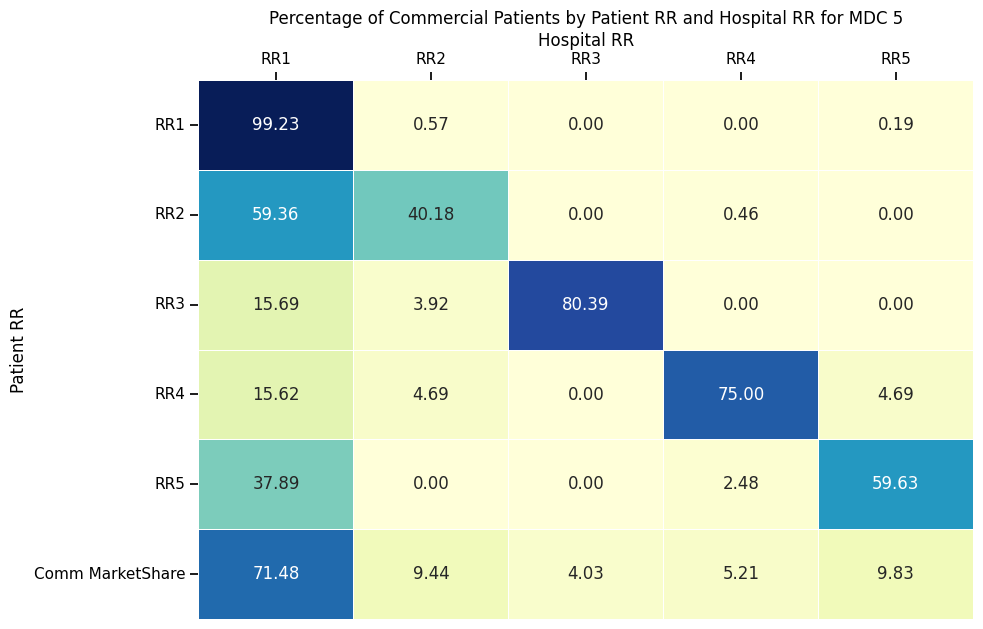

In [80]:
# Create heatmap
# Increase font sizes
sns.set_context("notebook")  # Adjust font size for a poster

plt.figure(figsize=(10, 7))

sns.heatmap(commercial_pivot_final, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=0.5, cbar=False)
plt.title('Percentage of Commercial Patients by Patient RR and Hospital RR for MDC '+ str(mdc))
plt.xlabel('Hospital RR')
plt.ylabel('Patient RR')
plt.gca().xaxis.tick_top()  # Move x-axis labels to the top
plt.gca().xaxis.set_label_position('top')  # Set x-axis label position to top

plt.show()

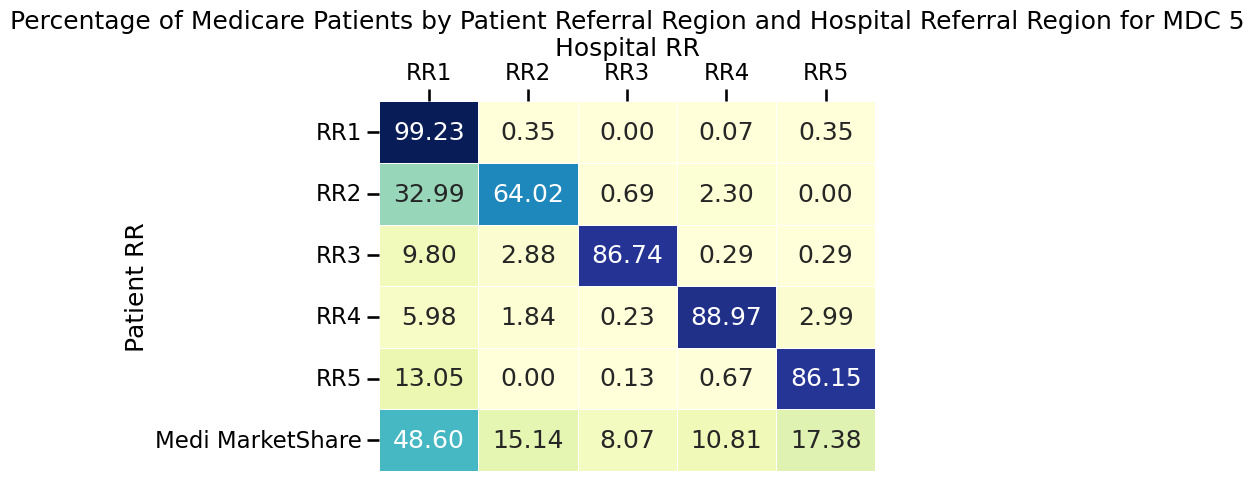

In [71]:
# Create heatmap
plt.figure()#figsize=(10, 6))
sns.heatmap(medicare_pivot_final, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=0.5, cbar=False)
plt.title('Percentage of Medicare Patients by Patient Referral Region and Hospital Referral Region for MDC '+ str(mdc))
plt.xlabel('Hospital RR')
plt.ylabel('Patient RR')
plt.gca().xaxis.tick_top()  # Move x-axis labels to the top
plt.gca().xaxis.set_label_position('top')  # Set x-axis label position to top

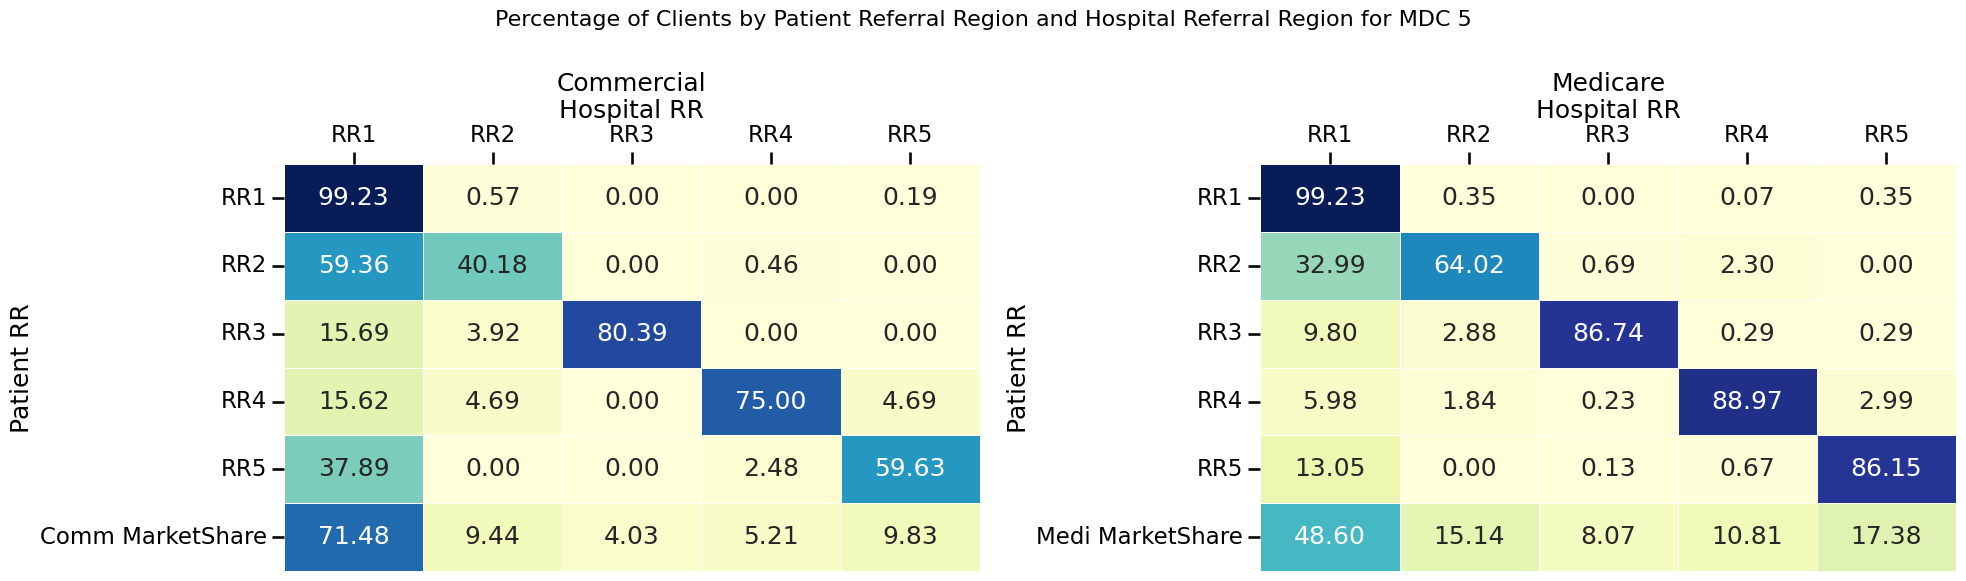

In [72]:
# Heatmaps for Commercial and Medicare
fig, axes = plt.subplots(1, 2, figsize=(20, 6))  # Create a figure with two subplots side by side

# Plot heatmap for the first matrix
sns.heatmap(commercial_pivot_final, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=0.5, cbar=False, ax=axes[0])
axes[0].set_title('Commercial')  # Set individual title for the first matrix
axes[0].set_xlabel('Hospital RR')  # Set x-axis label for the first matrix
axes[0].set_ylabel('Patient RR')  # Set y-axis label for the first matrix

# Move x-axis labels to the top for the first matrix
axes[0].xaxis.tick_top()
axes[0].xaxis.set_label_position('top')

# Plot heatmap for the second matrix
sns.heatmap(medicare_pivot_final, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=0.5, cbar=False, ax=axes[1])
axes[1].set_title('Medicare')  # Set individual title for the second matrix
axes[1].set_xlabel('Hospital RR')  # Set x-axis label for the second matrix
axes[1].set_ylabel('Patient RR')  # Set y-axis label for the second matrix

# Move x-axis labels to the top for the second matrix
axes[1].xaxis.tick_top()
axes[1].xaxis.set_label_position('top')

# Manually set rotation to 0 for both x-axis and y-axis labels of the right matrix
axes[1].tick_params(axis='x', rotation=0)
axes[1].tick_params(axis='y', rotation=0)

# Add main title for the entire figure
plt.suptitle('Percentage of Clients by Patient Referral Region and Hospital Referral Region for MDC '+ str(mdc), fontsize=16)

plt.tight_layout()  # Adjust layout to prevent overlap

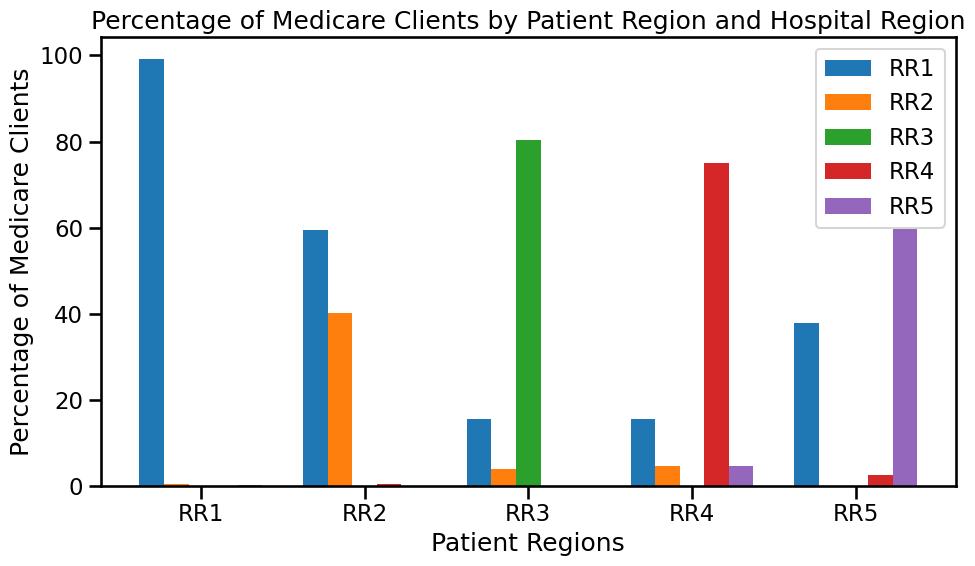

In [73]:
# Clustered bar chart
# Extracting hospital regions and patient regions
hospital_regions = commercial_pivot_final.columns
patient_regions = commercial_pivot_final.index.tolist()[:-1]

# Convert data to numpy array for plotting
percentages = np.array([commercial_pivot_final[region][:-1] for region in hospital_regions])

# Plotting
bar_width = 0.15
x = np.arange(len(patient_regions))

fig, ax = plt.subplots(figsize=(10, 6))

for i, region in enumerate(hospital_regions):
    ax.bar(x + (i - 2) * bar_width, percentages[i], width=bar_width, label=region)

ax.set_xlabel('Patient Regions')
ax.set_ylabel('Percentage of Medicare Clients')
ax.set_title('Percentage of Medicare Clients by Patient Region and Hospital Region')
ax.set_xticks(x)
ax.set_xticklabels(patient_regions)
ax.legend()

plt.tight_layout()
plt.show()

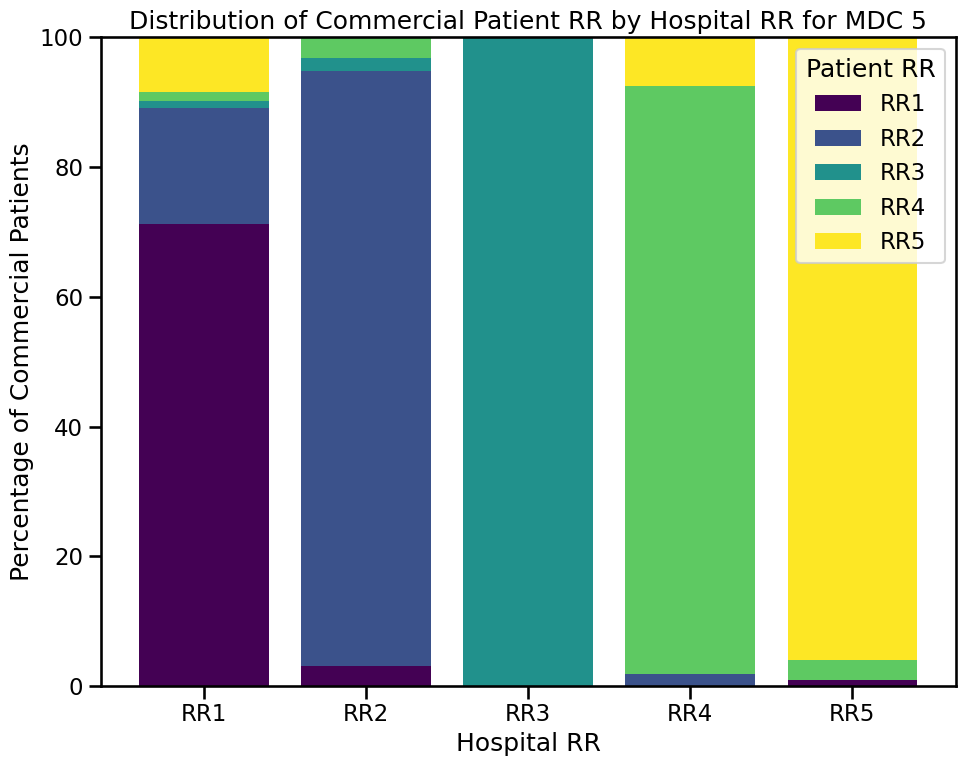

In [74]:
#Stacked bar chart v2
# Extracting hospital regions and patient regions
hospital_regions = commercial_pivot.columns[:-1]
patient_regions = commercial_pivot.index.tolist()[:-1]

# Convert data to numpy array for plotting
percentages = np.array([commercial_pivot[:-1][region] for region in patient_regions]).T

# Normalize the data to 100%
percentages_normalized = percentages / np.sum(percentages, axis=0, keepdims=True) * 100

# Plotting
# Increase font sizes
sns.set_context("talk")  # Adjust font size for a poster

bar_width = 0.1
x = np.arange(len(hospital_regions))

fig, ax = plt.subplots(figsize=(10, 8))

bottom = np.zeros(len(hospital_regions))

# Define color palette
colors = plt.cm.viridis(np.linspace(0, 1, len(patient_regions)))  # Using viridis colormap

for i, region in enumerate(patient_regions):
    ax.bar(x, percentages_normalized[i], bottom=bottom, label=region, color=colors[i])
    bottom += percentages_normalized[i]

ax.set_xlabel('Hospital RR')
ax.set_ylabel('Percentage of Commercial Patients')
ax.set_title('Distribution of Commercial Patient RR by Hospital RR for MDC '+ str(mdc))
ax.set_xticks(x)
ax.set_xticklabels(hospital_regions)
ax.legend(title='Patient RR')

plt.tight_layout()

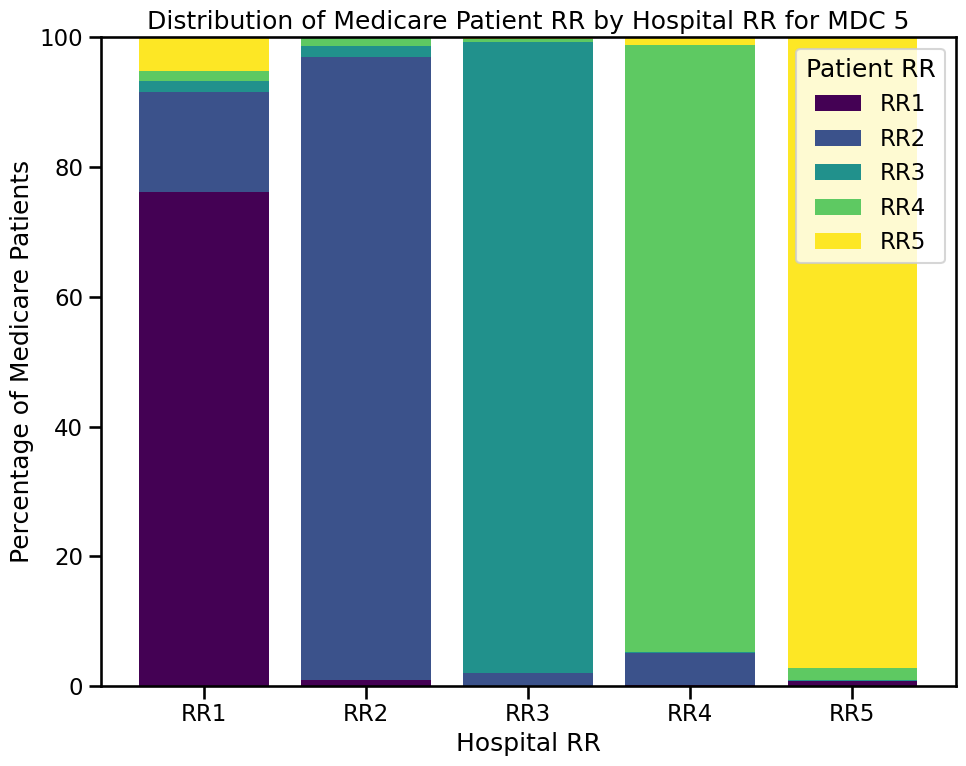

In [75]:
#Stacked bar chart v2
# Extracting hospital regions and patient regions
hospital_regions = medicare_pivot.columns[:-1]
patient_regions = medicare_pivot.index.tolist()[:-1]

# Convert data to numpy array for plotting
percentages = np.array([medicare_pivot[:-1][region] for region in patient_regions]).T

# Normalize the data to 100%
percentages_normalized = percentages / np.sum(percentages, axis=0, keepdims=True) * 100

# Plotting
# Increase font sizes
sns.set_context("talk")  # Adjust font size for a poster
bar_width = 0.5
x = np.arange(len(hospital_regions))

fig, ax = plt.subplots(figsize=(10, 8))

bottom = np.zeros(len(hospital_regions))

# Define color palette
colors = plt.cm.viridis(np.linspace(0, 1, len(patient_regions)))  # Using viridis colormap

for i, region in enumerate(patient_regions):
    ax.bar(x, percentages_normalized[i], bottom=bottom, label=region, color=colors[i])
    bottom += percentages_normalized[i]

ax.set_xlabel('Hospital RR')
ax.set_ylabel('Percentage of Medicare Patients')
ax.set_title('Distribution of Medicare Patient RR by Hospital RR for MDC '+ str(mdc))
ax.set_xticks(x)
ax.set_xticklabels(hospital_regions)
ax.legend(title='Patient RR')

plt.tight_layout()

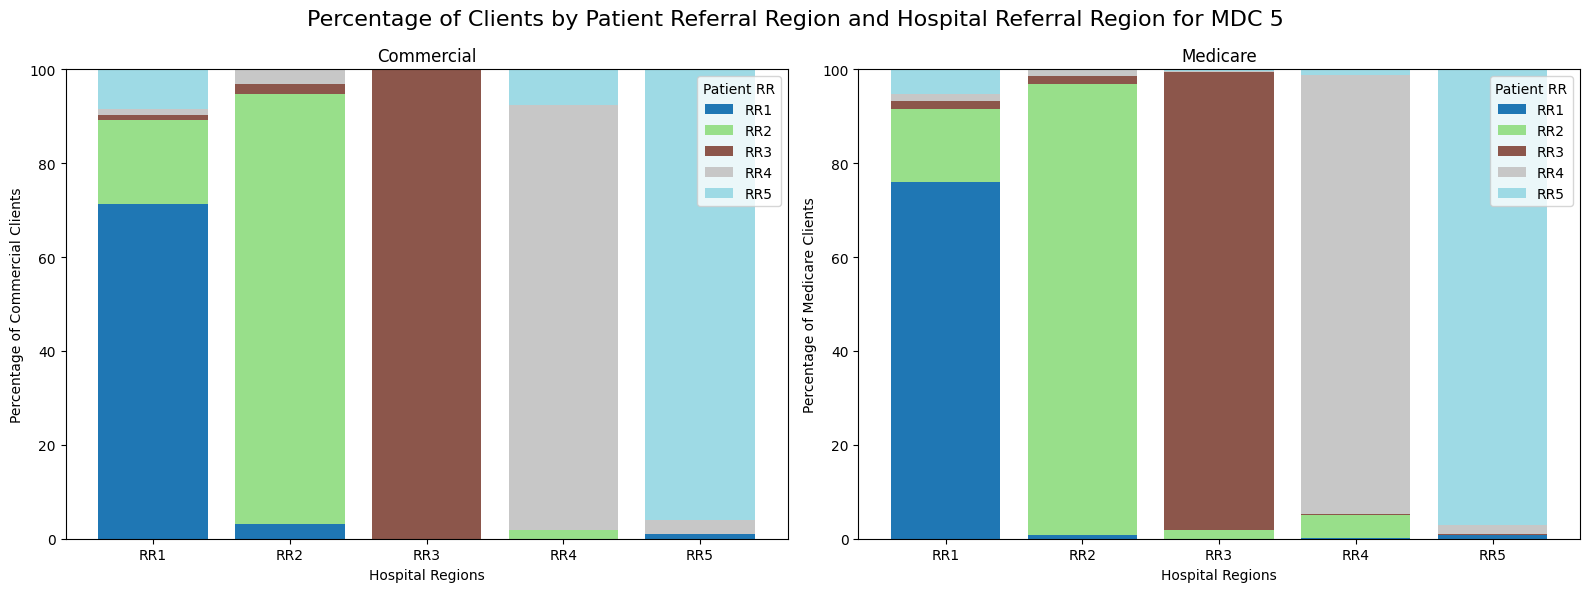

In [ ]:
# Extracting hospital regions and patient regions for the first plot
hospital_regions_1 = commercial_pivot.columns[:-1]
patient_regions_1 = commercial_pivot.index.tolist()[:-1]

# Extracting hospital regions and patient regions for the second plot (example data)
hospital_regions_2 = medicare_pivot.columns[:-1]
patient_regions_2 = medicare_pivot.index.tolist()[:-1]

percentages_2 = np.array([medicare_pivot[:-1][region] for region in patient_regions_2]).T
# Normalize the data to 100%
percentages_normalized_2 = percentages_2 / np.sum(percentages_2, axis=0, keepdims=True) * 100

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(16, 6))  # Create subplots with 1 row and 2 columns

# Plot for the first data
for ax in axs:  # Iterate over each subplot
    if ax == axs[0]:  # First subplot
        # Convert data to numpy array for plotting
        percentages = np.array([commercial_pivot[:-1][region] for region in patient_regions_1]).T

        # Normalize the data to 100%
        percentages_normalized = percentages / np.sum(percentages, axis=0, keepdims=True) * 100

        bottom = np.zeros(len(hospital_regions_1))  # Reset bottom values for each subplot
        colors = plt.cm.tab20(np.linspace(0, 1, len(patient_regions_1)))  # Define color palette

        for i, region in enumerate(patient_regions_1):
            axs[0].bar(hospital_regions_1, percentages_normalized[i], bottom=bottom, label=region, color=colors[i])
            bottom += percentages_normalized[i]

        axs[0].set_xlabel('Hospital Regions')
        axs[0].set_ylabel('Percentage of Commercial Clients')
        axs[0].set_title('Commercial')
        axs[0].legend(title='Patient RR')

    else:  # Second subplot
        bottom = np.zeros(len(hospital_regions_2))  # Reset bottom values for each subplot
        colors = plt.cm.tab20(np.linspace(0, 1, len(patient_regions_2)))  # Define color palette

        for i, region in enumerate(patient_regions_2):
            axs[1].bar(hospital_regions_2, percentages_normalized_2[i], bottom=bottom, label=region, color=colors[i])
            bottom += percentages_normalized_2[i]

        axs[1].set_xlabel('Hospital Regions')
        axs[1].set_ylabel('Percentage of Medicare Clients')
        axs[1].set_title('Medicare')
        axs[1].legend(title='Patient RR')

# Add main title for the entire figure
plt.suptitle('Percentage of Clients by Patient Referral Region and Hospital Referral Region for MDC '+ str(mdc), fontsize=16)

plt.tight_layout()
plt.show()

### MDC 5 DRGs

In [78]:
len([i for i in range(280, 317)])

37

In [79]:
inp_3 = inp_2.copy()

# for MDC 5 identify surgical vs medical
if mdc == 5:
    surgical_drgs = [i for i in range(215, 266)]
    medical_drgs = [i for i in range(280, 317)]

    inp_3['DRG'] = inp_3['DRG'].astype(int)

    condition_surgical = inp_3['DRG'].isin(surgical_drgs)
    condition_medical = inp_3['DRG'].isin(medical_drgs)

    # Define condition
    #condition_drg = ((condition_surgical) | (condition_medical))
    #inp_3 = inp_3[condition_drg]

    inp_3_s = inp_3[condition_surgical].copy()
    inp_3_m = inp_3[condition_medical].copy()

    # Creating new drg_type column
    inp_3_s.loc[condition_surgical, 'drg_type'] = 'surgical'
    inp_3_m.loc[condition_medical, 'drg_type'] = 'medical'

In [80]:
# Checking results
print(len(inp_3_s))
print(len(inp_3_m))
print(len(inp_3))

print(inp_3[~(condition_surgical | condition_medical)]['DRG'].value_counts())

1355
3963
5616
DRG
267    104
274     43
266     37
271     25
269     25
270     16
272     11
273      8
981      8
982      7
268      5
988      3
987      2
3        1
983      1
989      1
4        1
Name: count, dtype: int64


In [81]:
inp_3_s.groupby(['drg_type', 'RR_patient', 'RR_hosp'])['payer'].value_counts()

drg_type  RR_patient  RR_hosp  payer     
surgical  RR1         RR1      medicare      412
                               commercial    220
                      RR5      medicare        1
          RR2         RR1      medicare      141
                               commercial     79
                      RR2      medicare        8
                               commercial      2
          RR3         RR1      medicare       18
                               commercial      5
                      RR3      medicare        3
                               commercial      1
          RR4         RR1      medicare       12
                               commercial      4
                      RR4      medicare        4
                      RR5      medicare        1
          RR5         RR1      medicare       47
                               commercial     41
                      RR5      medicare       41
          Z_OutState  RR1      commercial    159
                           

Surgical

In [82]:
# For specified MDC, count number of customers for each RR

if mdc == 5:
    # Group by RR patient and RR hospital and get count of patients in each group
    count = inp_3_s.groupby(['drg_type', 'RR_patient', 'RR_hosp'])['payer'].value_counts().fillna(0).astype(int)
    count_df = count.unstack(fill_value=0).reset_index()

    # Total patients per patient region
    # Calculate total commercial patients per patient region
    count_df['total_commercial'] = count_df.groupby('RR_patient')['commercial'].transform('sum')
    # Calculate total medicare patients per patient region
    count_df['total_medicare'] = count_df.groupby('RR_patient')['medicare'].transform('sum')

    # % of patients for each hospital region within each patient region
    # Calculate percentage of commercial patients for each hospital region within each patient region
    count_df['commercial_%'] = (count_df['commercial'] / count_df['total_commercial']) * 100
    # Calculate percentage of medicare patients for each hospital region within each patient region
    count_df['medicare_%'] = (count_df['medicare'] / count_df['total_medicare']) * 100

    # Total patients per hospital region
    # Calculate total commercial patients per hospital region
    count_df['total_hospital_commercial'] = count_df.groupby('RR_hosp')['commercial'].transform('sum')
    # Calculate total medicare patients per hospital region
    count_df['total_hospital_medicare'] = count_df.groupby('RR_hosp')['medicare'].transform('sum')

    # Total patients across all regions
    # Calculate total commercial patients across all regions
    total_commercial_patients = count_df['commercial'].sum()
    # Calculate total medicare patients across all regions
    total_medicare_patients = count_df['medicare'].sum()

    # Market share for each hospital region
    # Calculate commercial market share for each hospital region
    count_df['Comm MarketShare'] = (count_df['total_hospital_commercial'] / total_commercial_patients) * 100
    # Calculate medicare market share for each hospital region
    count_df['Medi MarketShare'] = (count_df['total_hospital_medicare'] / total_medicare_patients) * 100

    count_df

        

In [83]:
if mdc == 5:
    # Pivot Table with Counts
    # Pivot table for commercial patients
    commercial_pivot_mdc5_s = count_df.pivot_table(index='RR_patient', columns='RR_hosp', values='commercial', fill_value=0, margins=True, aggfunc='sum').astype(int)

    # Pivot table for medicare patients
    medicare_pivot_mdc5_s = count_df.pivot_table(index='RR_patient', columns='RR_hosp', values='medicare', fill_value=0, margins=True, aggfunc='sum').astype(int)

    # Print the pivot tables
    print("O-D matrix with counts for Commercial patients MDC 5 Surgical:")
    print(commercial_pivot_mdc5_s)

    print("\nO-D matrix with counts for Medicare patients MDC 5 Surgical:")
    print(medicare_pivot_mdc5_s)

O-D matrix with counts for Commercial patients MDC 5 Surgical:
RR_hosp     RR1  RR2  RR3  RR4  RR5  All
RR_patient                              
RR1         220    0    0    0    0  220
RR2          79    2    0    0    0   81
RR3           5    0    1    0    0    6
RR4           4    0    0    0    0    4
RR5          41    0    0    0    0   41
Z_OutState  159    0    0    0    1  160
All         508    2    1    0    1  512

O-D matrix with counts for Medicare patients MDC 5 Surgical:
RR_hosp     RR1  RR2  RR3  RR4  RR5  All
RR_patient                              
RR1         412    0    0    0    1  413
RR2         141    8    0    0    0  149
RR3          18    0    3    0    0   21
RR4          12    0    0    4    1   17
RR5          47    0    0    0   41   88
Z_OutState  147    0    0    0    8  155
All         777    8    3    4   51  843


In [84]:
if mdc == 5:
    # Pivot Table with Percentages
    # Pivot table for commercial patients
    commercial_pivot_perc = count_df.pivot_table(index='RR_patient', columns='RR_hosp', values='commercial_%', fill_value=0)
    # Add a row for the total for each patient region
    #commercial_pivot_perc['Total'] = commercial_pivot_perc.sum(axis=1)
    # Add a row for the market share of each hospital region
    commercial_market_share_row = count_df.pivot_table(index=None, columns='RR_hosp', values='Comm MarketShare', aggfunc='first')
    #commercial_market_share_row.loc['Market Share'] = commercial_market_share_row.sum()
    # Concatenate the market share row to the pivot table
    commercial_pivot_final_mdc5_s = pd.concat([commercial_pivot_perc, commercial_market_share_row]).round(2)

    # Pivot table for medicare patients
    medicare_pivot_perc = count_df.pivot_table(index='RR_patient', columns='RR_hosp', values='medicare_%', fill_value=0)
    # Add a row for the total for each patient region
    #medicare_pivot_perc['Total'] = medicare_pivot_perc.sum(axis=1)
    # Add a row for the market share of each hospital region
    medicare_market_share_row = count_df.pivot_table(index=None, columns='RR_hosp', values='Medi MarketShare', aggfunc='first')
    #medicare_market_share_row.loc['Market Share'] = medicare_market_share_row.sum()
    # Concatenate the market share row to the pivot table
    medicare_pivot_final_mdc5_s = pd.concat([medicare_pivot_perc, medicare_market_share_row]).round(2)

    # Print the pivot tables
    print("O-D matrix with percentages for commercial patients MDC 5 Surgical:")
    print(commercial_pivot_final_mdc5_s)

    print("\nO-D matrix with percentages for medicare patients MDC 5 Surgical:")
    print(medicare_pivot_final_mdc5_s)

O-D matrix with percentages for commercial patients MDC 5 Surgical:
RR_hosp              RR1   RR2    RR3  RR4   RR5
RR1               100.00  0.00   0.00  0.0  0.00
RR2                97.53  2.47   0.00  0.0  0.00
RR3                83.33  0.00  16.67  0.0  0.00
RR4               100.00  0.00   0.00  0.0  0.00
RR5               100.00  0.00   0.00  0.0  0.00
Z_OutState         99.38  0.00   0.00  0.0  0.62
Comm MarketShare   99.22  0.39   0.20  0.0  0.20

O-D matrix with percentages for medicare patients MDC 5 Surgical:
RR_hosp             RR1   RR2    RR3    RR4    RR5
RR1               99.76  0.00   0.00   0.00   0.24
RR2               94.63  5.37   0.00   0.00   0.00
RR3               85.71  0.00  14.29   0.00   0.00
RR4               70.59  0.00   0.00  23.53   5.88
RR5               53.41  0.00   0.00   0.00  46.59
Z_OutState        94.84  0.00   0.00   0.00   5.16
Medi MarketShare  92.17  0.95   0.36   0.47   6.05


Medical

In [85]:
# For specified MDC, count number of customers for each RR

if mdc == 5:
    # Group by RR patient and RR hospital and get count of patients in each group
    count = inp_3_m.groupby(['drg_type', 'RR_patient', 'RR_hosp'])['payer'].value_counts().fillna(0).astype(int)
    count_df = count.unstack(fill_value=0).reset_index()

    # Total patients per patient region
    # Calculate total commercial patients per patient region
    count_df['total_commercial'] = count_df.groupby('RR_patient')['commercial'].transform('sum')
    # Calculate total medicare patients per patient region
    count_df['total_medicare'] = count_df.groupby('RR_patient')['medicare'].transform('sum')

    # % of patients for each hospital region within each patient region
    # Calculate percentage of commercial patients for each hospital region within each patient region
    count_df['commercial_%'] = (count_df['commercial'] / count_df['total_commercial']) * 100
    # Calculate percentage of medicare patients for each hospital region within each patient region
    count_df['medicare_%'] = (count_df['medicare'] / count_df['total_medicare']) * 100

    # Total patients per hospital region
    # Calculate total commercial patients per hospital region
    count_df['total_hospital_commercial'] = count_df.groupby('RR_hosp')['commercial'].transform('sum')
    # Calculate total medicare patients per hospital region
    count_df['total_hospital_medicare'] = count_df.groupby('RR_hosp')['medicare'].transform('sum')

    # Total patients across all regions
    # Calculate total commercial patients across all regions
    total_commercial_patients = count_df['commercial'].sum()
    # Calculate total medicare patients across all regions
    total_medicare_patients = count_df['medicare'].sum()

    # Market share for each hospital region
    # Calculate commercial market share for each hospital region
    count_df['Comm MarketShare'] = (count_df['total_hospital_commercial'] / total_commercial_patients) * 100
    # Calculate medicare market share for each hospital region
    count_df['Medi MarketShare'] = (count_df['total_hospital_medicare'] / total_medicare_patients) * 100

    count_df

In [86]:
if mdc == 5:
    # Pivot Table with Counts
    # Pivot table for commercial patients
    commercial_pivot_mdc5_m = count_df.pivot_table(index='RR_patient', columns='RR_hosp', values='commercial', fill_value=0, margins=True, aggfunc='sum').astype(int)

    # Pivot table for medicare patients
    medicare_pivot_mdc5_m = count_df.pivot_table(index='RR_patient', columns='RR_hosp', values='medicare', fill_value=0, margins=True, aggfunc='sum').astype(int)

    # Print the pivot tables
    print("O-D matrix with counts for Commercial patients MDC 5 Medical:")
    print(commercial_pivot_mdc5_m)

    print("\nO-D matrix with counts for Medicare patients MDC 5 Medical:")
    print(medicare_pivot_mdc5_m)

O-D matrix with counts for Commercial patients MDC 5 Medical:
RR_hosp     RR1  RR2  RR3  RR4  RR5  All
RR_patient                              
RR1         273    3    0    0    1  277
RR2          42   85    0    1    0  128
RR3           3    2   39    0    0   44
RR4           4    3    0   48    3   58
RR5          17    0    0    4   96  117
Z_OutState   82    3    3   10   18  116
All         421   96   42   63  118  740

O-D matrix with counts for Medicare patients MDC 5 Medical:
RR_hosp      RR1  RR2  RR3  RR4  RR5   All
RR_patient                                
RR1          910    5    0    1    4   920
RR2          111  546    6   20    0   683
RR3           12   10  295    1    1   319
RR4           11    7    1  382   12   413
RR5           36    0    1    5  602   644
Z_OutState    85   12    6   36  105   244
All         1165  580  309  445  724  3223


In [87]:
if mdc == 5:
    # Pivot Table with Percentages
    # Pivot table for commercial patients
    commercial_pivot_perc = count_df.pivot_table(index='RR_patient', columns='RR_hosp', values='commercial_%', fill_value=0)
    # Add a row for the total for each patient region
    #commercial_pivot_perc['Total'] = commercial_pivot_perc.sum(axis=1)
    # Add a row for the market share of each hospital region
    commercial_market_share_row = count_df.pivot_table(index=None, columns='RR_hosp', values='Comm MarketShare', aggfunc='first')
    #commercial_market_share_row.loc['Market Share'] = commercial_market_share_row.sum()
    # Concatenate the market share row to the pivot table
    commercial_pivot_final_mdc5_m = pd.concat([commercial_pivot_perc, commercial_market_share_row]).round(2)

    # Pivot table for medicare patients
    medicare_pivot_perc = count_df.pivot_table(index='RR_patient', columns='RR_hosp', values='medicare_%', fill_value=0)
    # Add a row for the total for each patient region
    #medicare_pivot_perc['Total'] = medicare_pivot_perc.sum(axis=1)
    # Add a row for the market share of each hospital region
    medicare_market_share_row = count_df.pivot_table(index=None, columns='RR_hosp', values='Medi MarketShare', aggfunc='first')
    #medicare_market_share_row.loc['Market Share'] = medicare_market_share_row.sum()
    # Concatenate the market share row to the pivot table
    medicare_pivot_final_mdc5_m = pd.concat([medicare_pivot_perc, medicare_market_share_row]).round(2)

    # Print the pivot tables
    print("O-D matrix with percentages for commercial patients MDC 5 Medical:")
    print(commercial_pivot_final_mdc5_m)

    print("\nO-D matrix with percentages for medicare patients MDC 5 Medical:")
    print(medicare_pivot_final_mdc5_m)

O-D matrix with percentages for commercial patients MDC 5 Medical:
RR_hosp             RR1    RR2    RR3    RR4    RR5
RR1               98.56   1.08   0.00   0.00   0.36
RR2               32.81  66.41   0.00   0.78   0.00
RR3                6.82   4.55  88.64   0.00   0.00
RR4                6.90   5.17   0.00  82.76   5.17
RR5               14.53   0.00   0.00   3.42  82.05
Z_OutState        70.69   2.59   2.59   8.62  15.52
Comm MarketShare  56.89  12.97   5.68   8.51  15.95

O-D matrix with percentages for medicare patients MDC 5 Medical:
RR_hosp             RR1    RR2    RR3    RR4    RR5
RR1               98.91   0.54   0.00   0.11   0.43
RR2               16.25  79.94   0.88   2.93   0.00
RR3                3.76   3.13  92.48   0.31   0.31
RR4                2.66   1.69   0.24  92.49   2.91
RR5                5.59   0.00   0.16   0.78  93.48
Z_OutState        34.84   4.92   2.46  14.75  43.03
Medi MarketShare  36.15  18.00   9.59  13.81  22.46


In [88]:
#pip install xlsxwriter

In [89]:
# Create an Excel writer object
writer = pd.ExcelWriter('OD_matrices_mdc5.xlsx', engine='xlsxwriter')

# Write dataframes to Excel sheets
commercial_pivot_mdc5_s.to_excel(writer, sheet_name='commercial_count_mdc5_s', index=True)
medicare_pivot_mdc5_s.to_excel(writer, sheet_name='medicare_count_mdc5_s', index=True)
commercial_pivot_final_mdc5_s.to_excel(writer, sheet_name='commercial_%_mdc5_s', index=True)
medicare_pivot_final_mdc5_s.to_excel(writer, sheet_name='medicare_%_mdc5_s', index=True)

commercial_pivot_mdc5_m.to_excel(writer, sheet_name='commercial_count_mdc5_m', index=True)
medicare_pivot_mdc5_m.to_excel(writer, sheet_name='medicare_count_mdc5_m', index=True)
commercial_pivot_final_mdc5_m.to_excel(writer, sheet_name='commercial_%_mdc5_m', index=True)
medicare_pivot_final_mdc5_m.to_excel(writer, sheet_name='medicare_%_mdc5_m', index=True)

# Save the Excel file
# Close the Excel writer object
writer.close()